# Chapter 5.1 Time-course Suite

**TL;DR** — Reproduces the Section 5.1 EB time-course suite as a tutorial, showing observed versus hidden time points, local versus shared bridges, and endpoint metrics. The reader finishes with Section 5.1 CSV tables, `run_summary.json`, and four Figure 5.1 panel images.

**Prerequisites** - Chapter 3.2 (EB CFM training) and Chapter 4.1 (coupling geometry). The CFM training loop is not repeated here; see chapter3_2 cell 18.

**Outputs**
- `figures/ch05/fig5_1_time_pair_designs.png`
- `figures/ch05/fig5_1_hidden_t2_recovery.png`
- `figures/ch05/fig5_1_seen_t4_rollout.png`
- `figures/ch05/fig5_1_velocity_jump.png`
- `tables/ch05/tab_5_1_main_suite.csv`
- `tables/ch05/tab_5_1_main_suite_summary.csv`
- `tables/ch05/tab_5_1_main_suite_diag.csv`
- `tables/ch05/tab_5_1_main_suite_diag_summary.csv`
- `tables/ch05/tab_5_1_main_text_results.csv`
- `outputs/ch05/run_summary.json`

**Runtime** - This notebook does not define `QUICK_MODE` or `SMOKE_MODE`; run size is controlled by Section 5.1 environment knobs such as seeds, EB max cells, batch size, NFE, and training steps in the variant specs. On CPU, this is a long training notebook because it trains local and shared bridges across multiple seeds.

**Key parameters**
- `DEFAULT_SEED` defaults to `42` via `CH05_SEED`.
- `SECTION51_MAIN_SUITE_SEEDS` defaults to `[42, 43, 44]`.
- `BATCH_SIZE` defaults to `256`; `NFE` defaults to `32`.
- EB max cells per time defaults to `900` through the Section 5.1 config.
- Pairwise local bridges use `6000 // len(adjacent_pairs)` steps per adjacent bridge.
- Shared bridge variants use `6000` or `9000` total training steps, depending on the variant spec.

## 1. What this experiment tests

The EB data contain single-cell snapshots at five ordered time points. We train flow-matching bridges from the initial snapshot and ask two complementary questions:

- Can a model recover the hidden intermediate population at `t2`?
- Can a model roll out to the seen endpoint `t4` without accumulating too much long-horizon error?
- Are velocities smooth across hand-off points where pairwise local bridges switch from one local model to the next?

The comparison is deliberately small: pairwise local bridges, one shared adjacent-only field, and two shared fields that also see skip pairs.


## 2. Setup and reproducibility controls

The setup cell keeps only environment and import mechanics. Reusable path, IO, display, plotting, and audit helpers live in `src.experiments.timecourse_config`; the experimental steps below remain visible in this notebook.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch05_section51")

from pathlib import Path

import sys

ROOT_HINT = Path.cwd().resolve()
if not (ROOT_HINT / "src").is_dir():
    ROOT_HINT = ROOT_HINT.parent
if str(ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(ROOT_HINT))

from src.tutorial_init import apply_tutorial_plot_style, bootstrap, make_save_and_show

DEFAULT_SEED = int(os.environ.get("CH05_SEED", "42"))
boot = bootstrap(chapter="ch05", seed=DEFAULT_SEED, quick_mode=None)
PROJECT_ROOT = boot.project_root
FIG_DIR = boot.fig_dir
OUT_DIR = boot.out_dir
DEVICE = boot.device

print("Project root resolved.")


project_root=..
seed=42
quick_mode=None
fig_dir=figures/ch05
out_dir=outputs/ch05
device=cuda
Project root resolved.


In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.experiments.timecourse import (
    _global_rollout,
    _local_sequence_rollout,
    _train_global_bridge_model,
    _train_local_bridge,
    build_ch05_section51_main_text_results,
    endpoint_distribution_metrics,
    load_eb_ch05,
    set_global_seed,
    summarize_eb_section51_main_suite,
)
from src.visualization.timecourse import (
    build_fig5_1_panel_tables,
    draw_fig5_1_hidden_t2_panel,
    draw_fig5_1_seen_t4_panel,
    draw_fig5_1_time_pair_designs,
    draw_fig5_1_velocity_jump_panel,
    register_fig5_1_artifacts,
)
from src.experiments.timecourse_config import (
    audit_section51_main_text_results,
    json_ready,
    make_section51_config,
    preview_frame,
    verify_expected_display_values,
    write_section51_artifacts,
)


In [3]:
CONFIG = make_section51_config(PROJECT_ROOT)
FIG_DIR = CONFIG.fig_dir
TABLE_DIR = CONFIG.table_dir
OUTPUT_DIR = CONFIG.output_dir
DEFAULT_SEED = CONFIG.default_seed
SECTION51_MAIN_SUITE_SEEDS = CONFIG.suite_seeds
BATCH_SIZE = CONFIG.batch_size
NFE = CONFIG.nfe
EB_MAX_CELLS_PER_TIME = CONFIG.eb_max_cells_per_time
DEVICE = CONFIG.device

apply_tutorial_plot_style()
save_and_show = make_save_and_show(FIG_DIR, write_pdf=False)
print(f"Device: {DEVICE}; batch={BATCH_SIZE}; nfe={NFE}")
print(f"Seeds: {SECTION51_MAIN_SUITE_SEEDS}")
print(f"EB max cells per time: {EB_MAX_CELLS_PER_TIME}")


Device: cuda; batch=256; nfe=32
Seeds: [42, 43, 44]
EB max cells per time: 900


## 3. Load EB data

The loader standardizes the PC representation, keeps a balanced maximum number of cells per time point, and returns dictionaries keyed by the original time labels. We keep `t2` hidden for interpolation-style evaluation and use `t4` as a long-horizon endpoint check.


In [4]:
eb = load_eb_ch05(
    CONFIG.eb_path,
    max_cells_per_time=EB_MAX_CELLS_PER_TIME,
    seed=DEFAULT_SEED,
    n_pc=20,
)

by_time = eb["by_time"]
time_values = eb["time_values"]
print(f"EB path: {CONFIG.eb_path.relative_to(PROJECT_ROOT)}")
print("Time values:", time_values)
preview_frame(eb["counts"], n=10)


EB path: data/trajectorynet_eb/eb_velocity_v5.npz
Time values: {'0': 0.0, '1': 0.25, '2': 0.5, '3': 0.75, '4': 1.0}


,time,n_cells
0,0,900
1,1,900
2,2,900
3,3,900
4,4,900


,time,n_cells
0,0,900
1,1,900
2,2,900
3,3,900
4,4,900


## 4. Define pair topology and model variants

The topology is the experimental design. Pairwise local bridges train one model per adjacent interval. Shared models train one global velocity field over several source-target pairs. Skip supervision adds longer pairs so the field sees nonlocal constraints, but the weighting controls whether skip pairs dominate the adjacent pairs.


In [5]:
adjacent_pairs = [("0", "1"), ("1", "3"), ("3", "4")]
skip_pairs = adjacent_pairs + [("0", "3"), ("1", "4"), ("0", "4")]

main_method_variants = [
    "pairwise_local_bridges_6000",
    "shared_adjacent_only_6000",
    "shared_skip_adj2_skip1_9000",
]

shared_specs = [
    {
        "variant": "shared_adjacent_only_6000",
        "variant_family": "shared_adjacent",
        "pairs": adjacent_pairs,
        "training_steps_total": 6000,
        "sampling": "uniform_adjacent",
        "pair_weights": None,
        "seed_offset": 30,
    },
    {
        "variant": "shared_skip_uniform_6000",
        "variant_family": "shared_skip",
        "pairs": skip_pairs,
        "training_steps_total": 6000,
        "sampling": "uniform_adjacent_skip",
        "pair_weights": None,
        "seed_offset": 40,
    },
    {
        "variant": "shared_skip_adj2_skip1_9000",
        "variant_family": "shared_skip",
        "pairs": skip_pairs,
        "training_steps_total": 9000,
        "sampling": "adjacent_total_2_3_skip_total_1_3",
        "pair_weights": [2.0, 2.0, 2.0, 1.0, 1.0, 1.0],
        "seed_offset": 50,
    },
]

analysis_specs = [
    spec for spec in shared_specs
    if spec["variant"] in main_method_variants
]

print("Adjacent pairs:", adjacent_pairs)
print("Skip pairs:", skip_pairs)
print("Shared training specs:", [spec["variant"] for spec in shared_specs])
print("Main methods:", main_method_variants)


Adjacent pairs: [('0', '1'), ('1', '3'), ('3', '4')]
Skip pairs: [('0', '1'), ('1', '3'), ('3', '4'), ('0', '3'), ('1', '4'), ('0', '4')]
Shared training specs: ['shared_adjacent_only_6000', 'shared_skip_uniform_6000', 'shared_skip_adj2_skip1_9000']
Main methods: ['pairwise_local_bridges_6000', 'shared_adjacent_only_6000', 'shared_skip_adj2_skip1_9000']


In [6]:
variant_table = pd.DataFrame([
    {
        "variant": "pairwise_local_bridges_6000",
        "family": "pairwise",
        "pairs": ";".join(f"{a}-{b}" for a, b in adjacent_pairs),
        "steps": 6000,
        "sampling": "local_pairwise",
    },
    *[
        {
            "variant": spec["variant"],
            "family": spec["variant_family"],
            "pairs": ";".join(f"{a}-{b}" for a, b in spec["pairs"]),
            "steps": spec["training_steps_total"],
            "sampling": spec["sampling"],
        }
        for spec in analysis_specs
    ],
])
control_table = pd.DataFrame([
    {
        "variant": spec["variant"],
        "family": spec["variant_family"],
        "pairs": ";".join(f"{a}-{b}" for a, b in spec["pairs"]),
        "steps": spec["training_steps_total"],
        "sampling": spec["sampling"],
    }
    for spec in shared_specs
    if spec["variant"] not in main_method_variants
])
preview_frame(variant_table, n=10)
if not control_table.empty:
    print("Training-only control specs used for legacy RNG alignment")
    preview_frame(control_table, n=10)


,variant,family,pairs,steps,sampling
0,pairwise_local_bridges_6000,pairwise,0-1;1-3;3-4,6000,local_pairwise
1,shared_adjacent_only_6000,shared_adjacent,0-1;1-3;3-4,6000,uniform_adjacent
2,shared_skip_adj2_skip1_9000,shared_skip,0-1;1-3;3-4;0-3;1-4;0-4,9000,adjacent_total_2_3_skip_total_1_3


Training-only control specs used for legacy RNG alignment


,variant,family,pairs,steps,sampling
0,shared_skip_uniform_6000,shared_skip,0-1;1-3;3-4;0-3;1-4;0-4,6000,uniform_adjacent_skip


## 5. Train pairwise local bridges

A pairwise baseline trains one independent bridge per adjacent interval. This is easy to interpret, but its velocity field is not globally shared, so rollouts must stitch local bridges together at hand-off times.

The CFM velocity-regression training loop is the same `cfm_loss_from_pairs` pattern used earlier in the tutorial sequence: sample endpoint pairs, regress the conditional velocity, then run `zero_grad`, `backward`, and optimizer `step`. Here `_train_local_bridge` wraps that loop so this section can focus on the time-pair topology and hand-off design rather than repeating the Chapter 3 training mechanics.


In [7]:
pair_steps = 6000 // len(adjacent_pairs)
pair_models_by_seed = {}
rng_state_after_pairwise_by_seed = {}
histories = {}

for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    set_global_seed(DEFAULT_SEED)
    pair_models = {}
    for pair_idx, pair in enumerate(adjacent_pairs):
        model, hist = _train_local_bridge(
            by_time[pair[0]],
            by_time[pair[1]],
            pair_steps,
            BATCH_SIZE,
            int(run_seed) + 10 + pair_idx,
            device=DEVICE,
        )
        pair_models[pair] = model
        histories[(int(run_seed), f"pairwise_{pair[0]}_{pair[1]}")] = hist
    pair_models_by_seed[int(run_seed)] = pair_models
    rng_state_after_pairwise_by_seed[int(run_seed)] = {
        "cpu": torch.random.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }

print(f"Trained {len(pair_models_by_seed) * len(adjacent_pairs)} local bridges")
print("Pairwise steps per local bridge:", pair_steps)


Trained 9 local bridges
Pairwise steps per local bridge: 2000


## 6. Train shared global bridges

The shared models use one velocity field across multiple source-target pairs. The adjacent-only shared model tests whether global sharing helps recover a hidden intermediate snapshot. The skip variants test whether long-range pair supervision helps endpoint rollout.

`_train_global_bridge_model` uses the same CFM velocity-regression training loop as `_train_local_bridge`, but each mini-batch first chooses one of the configured time pairs and passes the normalized source/target times into the velocity model. `shared_specs` intentionally includes the legacy uniform-skip control before the weighted 2:1 skip model so the training RNG stream matches the archived Section 5.1 run; `analysis_specs` keeps the paper-facing analysis to the three main methods.


In [8]:
shared_models_by_seed = {}

for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    torch.random.set_rng_state(rng_state_after_pairwise_by_seed[run_seed]["cpu"])
    cuda_state = rng_state_after_pairwise_by_seed[run_seed]["cuda"]
    if cuda_state is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(cuda_state)

    shared_models = {}
    for spec in shared_specs:
        model, hist = _train_global_bridge_model(
            by_time,
            spec["pairs"],
            time_values,
            int(spec["training_steps_total"]),
            BATCH_SIZE,
            run_seed + int(spec["seed_offset"]),
            device=DEVICE,
            pair_weights=spec["pair_weights"],
        )
        shared_models[spec["variant"]] = model
        histories[(run_seed, spec["variant"])] = hist
    shared_models_by_seed[run_seed] = shared_models

print(f"Trained {len(shared_models_by_seed) * len(shared_specs)} shared training/control models")
print("Stored history keys:", len(histories))


Trained 9 shared training/control models
Stored history keys: 18


## 7. Roll out predictions

Every variant starts from the observed `t0` population. We evaluate two endpoints: hidden `t2` at global time `0.50`, and seen `t4` at global time `1.00`. Pairwise rollouts stitch local bridges; shared rollouts integrate one global field.


In [9]:
X0 = by_time["0"]
targets = {"hidden_t2": by_time["2"], "seen_t4": by_time["4"]}
predictions_by_seed = {}
print("Evaluation targets:", sorted(targets.keys()))


Evaluation targets: ['hidden_t2', 'seen_t4']


In [10]:
for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    pair_models = pair_models_by_seed[run_seed]
    predictions_by_seed[run_seed] = {
        "pairwise_local_bridges_6000": {
            "variant_family": "pairwise",
            "training_steps_total": int(pair_steps * len(adjacent_pairs)),
            "sampling": "local_pairwise",
            "pairs": adjacent_pairs,
            "pair_weights": "",
            "hidden_t2": _local_sequence_rollout(
                pair_models,
                X0,
                [(("0", "1"), 1.0), (("1", "3"), 0.5)],
                NFE,
                device=DEVICE,
            ),
            "seen_t4": _local_sequence_rollout(
                pair_models,
                X0,
                [(("0", "1"), 1.0), (("1", "3"), 1.0), (("3", "4"), 1.0)],
                NFE,
                device=DEVICE,
            ),
        }
    }

print("Pairwise predictions complete:", len(predictions_by_seed))


Pairwise predictions complete: 3


In [11]:
for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    for spec in analysis_specs:
        model = shared_models_by_seed[run_seed][spec["variant"]]
        weights = spec["pair_weights"]
        pair_weights = "uniform" if weights is None else ",".join(
            f"{w:.6g}" for w in (np.asarray(weights, dtype=float) / np.sum(weights))
        )
        predictions_by_seed[run_seed][spec["variant"]] = {
            "variant_family": spec["variant_family"],
            "training_steps_total": int(spec["training_steps_total"]),
            "sampling": spec["sampling"],
            "pairs": spec["pairs"],
            "pair_weights": pair_weights,
            "hidden_t2": _global_rollout(model, X0, 0.5, NFE * 2, device=DEVICE),
            "seen_t4": _global_rollout(model, X0, 1.0, NFE * 4, device=DEVICE),
        }

print("Prediction variants:", sorted(next(iter(predictions_by_seed.values())).keys()))


Prediction variants: ['pairwise_local_bridges_6000', 'shared_adjacent_only_6000', 'shared_skip_adj2_skip1_9000']


## 8. Compute endpoint metrics

The endpoint table is one row per seed, variant, and target. Lower MMD, sliced Wasserstein, and centroid distance all indicate closer agreement between a rollout population and the held-out or endpoint snapshot.


In [12]:
rows = []
for run_seed, predictions in predictions_by_seed.items():
    for variant, payload in predictions.items():
        for target_name in ["hidden_t2", "seen_t4"]:
            metrics = endpoint_distribution_metrics(payload[target_name], targets[target_name])
            rows.append(
                {
                    "experiment": "EB Section 5.1 main suite",
                    "seed": int(run_seed),
                    "variant": variant,
                    "variant_family": payload["variant_family"],
                    "target": target_name,
                    "training_steps_total": int(payload["training_steps_total"]),
                    "sampling": payload["sampling"],
                    "pairs": ";".join(f"{a}-{b}" for a, b in payload["pairs"]),
                    "pair_weights": payload["pair_weights"],
                    "mmd_rbf": float(metrics["mmd_rbf"]),
                    "sliced_w2": float(metrics["sliced_w2"]),
                    "centroid_l2": float(metrics["centroid_l2"]),
                }
            )

section51_metrics = pd.DataFrame(rows)
print("Metrics shape:", section51_metrics.shape)
preview_frame(
    section51_metrics,
    columns=["seed", "variant", "target", "mmd_rbf", "sliced_w2", "centroid_l2"],
    n=8,
)


Metrics shape: (18, 12)


,seed,variant,target,mmd_rbf,sliced_w2,centroid_l2
0,42,pairwise_local_bridges_6000,hidden_t2,0.080739,0.402712,1.115312
1,42,pairwise_local_bridges_6000,seen_t4,0.007199,0.214815,0.678975
2,42,shared_adjacent_only_6000,hidden_t2,0.059406,0.376872,1.157762
3,42,shared_adjacent_only_6000,seen_t4,0.008241,0.188741,0.571825
4,42,shared_skip_adj2_skip1_9000,hidden_t2,0.063294,0.379612,1.318759
5,42,shared_skip_adj2_skip1_9000,seen_t4,0.008891,0.240142,0.767860
6,43,pairwise_local_bridges_6000,hidden_t2,0.085285,0.404628,1.120002
7,43,pairwise_local_bridges_6000,seen_t4,0.008277,0.157003,0.616723


,seed,variant,target,mmd_rbf,sliced_w2,centroid_l2
0,42,pairwise_local_bridges_6000,hidden_t2,0.080739,0.402712,1.115312
1,42,pairwise_local_bridges_6000,seen_t4,0.007199,0.214815,0.678975
2,42,shared_adjacent_only_6000,hidden_t2,0.059406,0.376872,1.157762
3,42,shared_adjacent_only_6000,seen_t4,0.008241,0.188741,0.571825
4,42,shared_skip_adj2_skip1_9000,hidden_t2,0.063294,0.379612,1.318759
5,42,shared_skip_adj2_skip1_9000,seen_t4,0.008891,0.240142,0.767860
6,43,pairwise_local_bridges_6000,hidden_t2,0.085285,0.404628,1.120002
7,43,pairwise_local_bridges_6000,seen_t4,0.008277,0.157003,0.616723


## 9. Compute hand-off diagnostics

Endpoint scores do not tell us whether the learned velocity field is smooth at the observed hand-off points. The diagnostic below compares the velocity just before and after `t1` and `t3`. Pairwise local bridges can jump because the left and right sides are different models.


In [13]:
diag_rows = []
boundary_specs = [("t1", "1", 0.25), ("t3", "3", 0.75)]
device_obj = torch.device(DEVICE)

for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    pair_models = pair_models_by_seed[run_seed]
    shared_models = shared_models_by_seed[run_seed]
    for boundary, boundary_time, t_global in boundary_specs:
        Xb = by_time[boundary_time]
        xb = torch.as_tensor(Xb, dtype=torch.float32, device=device_obj)
        left_pair = ("0", "1") if boundary == "t1" else ("1", "3")
        right_pair = ("1", "3") if boundary == "t1" else ("3", "4")
        with torch.no_grad():
            v_left = pair_models[left_pair](
                xb,
                torch.ones((len(Xb), 1), device=device_obj),
            ).detach().cpu().numpy()
            v_right = pair_models[right_pair](
                xb,
                torch.zeros((len(Xb), 1), device=device_obj),
            ).detach().cpu().numpy()
        diag_rows.append(
            {
                "experiment": "EB Section 5.1 main suite",
                "seed": int(run_seed),
                "variant": "pairwise_local_bridges_6000",
                "variant_family": "pairwise",
                "boundary": boundary,
                "training_steps_total": int(pair_steps * len(adjacent_pairs)),
                "sampling": "local_pairwise",
                "velocity_jump_mean_l2": float(np.linalg.norm(v_left - v_right, axis=1).mean()),
            }
        )
        for spec in analysis_specs:
            model = shared_models[spec["variant"]]
            with torch.no_grad():
                t_left = torch.full((len(Xb), 1), max(0.0, t_global - 0.01), device=device_obj)
                t_right = torch.full((len(Xb), 1), min(1.0, t_global + 0.01), device=device_obj)
                vl = model(xb, t_left).detach().cpu().numpy()
                vr = model(xb, t_right).detach().cpu().numpy()
            diag_rows.append(
                {
                    "experiment": "EB Section 5.1 main suite",
                    "seed": int(run_seed),
                    "variant": spec["variant"],
                    "variant_family": spec["variant_family"],
                    "boundary": boundary,
                    "training_steps_total": int(spec["training_steps_total"]),
                    "sampling": spec["sampling"],
                    "velocity_jump_mean_l2": float(np.linalg.norm(vl - vr, axis=1).mean()),
                }
            )

section51_diag = pd.DataFrame(diag_rows)
print("Diagnostics shape:", section51_diag.shape)
preview_frame(section51_diag, columns=["seed", "variant", "boundary", "velocity_jump_mean_l2"], n=8)


Diagnostics shape: (18, 8)


,seed,variant,boundary,velocity_jump_mean_l2
0,42,pairwise_local_bridges_6000,t1,8.053829
1,42,shared_adjacent_only_6000,t1,8.168670
2,42,shared_skip_adj2_skip1_9000,t1,8.994890
3,42,pairwise_local_bridges_6000,t3,8.590636
4,42,shared_adjacent_only_6000,t3,4.799015
5,42,shared_skip_adj2_skip1_9000,t3,4.212292
6,43,pairwise_local_bridges_6000,t1,8.040050
7,43,shared_adjacent_only_6000,t1,8.082140


,seed,variant,boundary,velocity_jump_mean_l2
0,42,pairwise_local_bridges_6000,t1,8.053829
1,42,shared_adjacent_only_6000,t1,8.168670
2,42,shared_skip_adj2_skip1_9000,t1,8.994890
3,42,pairwise_local_bridges_6000,t3,8.590636
4,42,shared_adjacent_only_6000,t3,4.799015
5,42,shared_skip_adj2_skip1_9000,t3,4.212292
6,43,pairwise_local_bridges_6000,t1,8.040050
7,43,shared_adjacent_only_6000,t1,8.082140


## 10. Summarize metrics into paper-facing tables

The raw tables keep seed-level rows. The summary tables average over seeds, and `build_ch05_section51_main_text_results` extracts only the values used by the paper text and claim audit.


In [14]:
section51_summary, section51_diag_summary = summarize_eb_section51_main_suite(
    section51_metrics,
    section51_diag,
)
section51_main_text_results, section51_summary_payload = build_ch05_section51_main_text_results(
    section51_summary,
    section51_diag_summary,
)

print("Summary shape:", section51_summary.shape)
print("Diagnostic summary shape:", section51_diag_summary.shape)
print("Main-text result shape:", section51_main_text_results.shape)
preview_frame(
    section51_summary,
    columns=["variant", "target", "mmd_rbf_mean", "sliced_w2_mean", "centroid_l2_mean", "n_seeds"],
    n=len(section51_summary),
)


Summary shape: (6, 12)
Diagnostic summary shape: (6, 8)
Main-text result shape: (25, 12)


,variant,target,mmd_rbf_mean,sliced_w2_mean,centroid_l2_mean,n_seeds
0,pairwise_local_bridges_6000,hidden_t2,0.083634,0.408452,1.127930,3
1,shared_adjacent_only_6000,hidden_t2,0.056502,0.355996,1.139057,3
2,shared_skip_adj2_skip1_9000,hidden_t2,0.067479,0.384300,1.221085,3
3,pairwise_local_bridges_6000,seen_t4,0.006871,0.172061,0.582460,3
4,shared_adjacent_only_6000,seen_t4,0.014107,0.321605,0.904182,3
5,shared_skip_adj2_skip1_9000,seen_t4,0.008896,0.214999,0.663832,3


,variant,target,mmd_rbf_mean,sliced_w2_mean,centroid_l2_mean,n_seeds
0,pairwise_local_bridges_6000,hidden_t2,0.083634,0.408452,1.127930,3
1,shared_adjacent_only_6000,hidden_t2,0.056502,0.355996,1.139057,3
2,shared_skip_adj2_skip1_9000,hidden_t2,0.067479,0.384300,1.221085,3
3,pairwise_local_bridges_6000,seen_t4,0.006871,0.172061,0.582460,3
4,shared_adjacent_only_6000,seen_t4,0.014107,0.321605,0.904182,3
5,shared_skip_adj2_skip1_9000,seen_t4,0.008896,0.214999,0.663832,3


## 11. Save official tables and run summary

This cell writes the Section 5.1 CSV tables and updates `run_summary.json`. The broad overview image is intentionally no longer generated here; the paper-facing visual record is the four independent Figure 5.1 panels in the next section.

Official artifacts preserved here:

- `tables/ch05/tab_5_1_main_suite.csv`
- `tables/ch05/tab_5_1_main_suite_summary.csv`
- `tables/ch05/tab_5_1_main_suite_diag.csv`
- `tables/ch05/tab_5_1_main_suite_diag_summary.csv`
- `tables/ch05/tab_5_1_main_text_results.csv`
- `outputs/ch05/run_summary.json`


In [15]:
artifact_paths = write_section51_artifacts(
    section51_metrics,
    section51_diag,
    section51_summary,
    section51_diag_summary,
    section51_main_text_results,
    section51_summary_payload,
    CONFIG,
)

for name, path in artifact_paths.items():
    print(f"{name}: {path.relative_to(PROJECT_ROOT)}")

main_text_path = artifact_paths["main_text"]
run_summary_path = artifact_paths["run_summary"]


metrics: tables/ch05/tab_5_1_main_suite.csv
summary: tables/ch05/tab_5_1_main_suite_summary.csv
diagnostics: tables/ch05/tab_5_1_main_suite_diag.csv
diagnostic_summary: tables/ch05/tab_5_1_main_suite_diag_summary.csv
main_text: tables/ch05/tab_5_1_main_text_results.csv
run_summary: outputs/ch05/run_summary.json


## 12. Redraw Figure 5.1 as independent paper panels

The cells below redraw the Section 5.1 main figure as four independent publication panels. Each panel is generated, displayed, and saved in its own code cell. The quantitative panels use seed-level tables from this notebook and show mean +/- SEM across seeds; no values are hand-entered in the plotting code.

Panel artifacts registered in `run_summary.json`:

- `figures/ch05/fig5_1_time_pair_designs.png`
- `figures/ch05/fig5_1_hidden_t2_recovery.png`
- `figures/ch05/fig5_1_seen_t4_rollout.png`
- `figures/ch05/fig5_1_velocity_jump.png`


In [16]:
# Use in-memory tables when the notebook has just generated them; fall back to saved tables for reruns from this section.
if "section51_metrics" not in globals():
    section51_metrics = pd.read_csv(TABLE_DIR / "tab_5_1_main_suite.csv")
if "section51_diag" not in globals():
    section51_diag = pd.read_csv(TABLE_DIR / "tab_5_1_main_suite_diag.csv")

fig5_1_tables = build_fig5_1_panel_tables(section51_metrics, section51_diag)
fig5_1_hidden_t2_values = fig5_1_tables.hidden_t2_values
fig5_1_seen_t4_values = fig5_1_tables.seen_t4_values
fig5_1_velocity_jump_values = fig5_1_tables.velocity_jump_values
fig5_1_panel_sources = fig5_1_tables.panel_sources
fig5_1_missing_entries = fig5_1_tables.missing_entries

print("Figure 5.1 three-method redraw setup ready")
print("Error bars: mean +/- SEM across seed-level rows; n=3 for all quantitative panels")
preview_frame(fig5_1_panel_sources, n=len(fig5_1_panel_sources))


Figure 5.1 three-method redraw setup ready
Error bars: mean +/- SEM across seed-level rows; n=3 for all quantitative panels


,panel,source_dataframe,source_table
0,Training time-pair designs,panel schematic,adjacent_pairs and skip_pairs defined in this ...
1,Hidden t=2 recovery,fig5_1_hidden_t2_values,tab_5_1_main_suite.csv / section51_metrics
2,Seen t=4 rollout,fig5_1_seen_t4_values,tab_5_1_main_suite.csv / section51_metrics
3,Velocity jump at hand-offs,fig5_1_velocity_jump_values,tab_5_1_main_suite_diag.csv / section51_diag


,panel,source_dataframe,source_table
0,Training time-pair designs,panel schematic,adjacent_pairs and skip_pairs defined in this ...
1,Hidden t=2 recovery,fig5_1_hidden_t2_values,tab_5_1_main_suite.csv / section51_metrics
2,Seen t=4 rollout,fig5_1_seen_t4_values,tab_5_1_main_suite.csv / section51_metrics
3,Velocity jump at hand-offs,fig5_1_velocity_jump_values,tab_5_1_main_suite_diag.csv / section51_diag


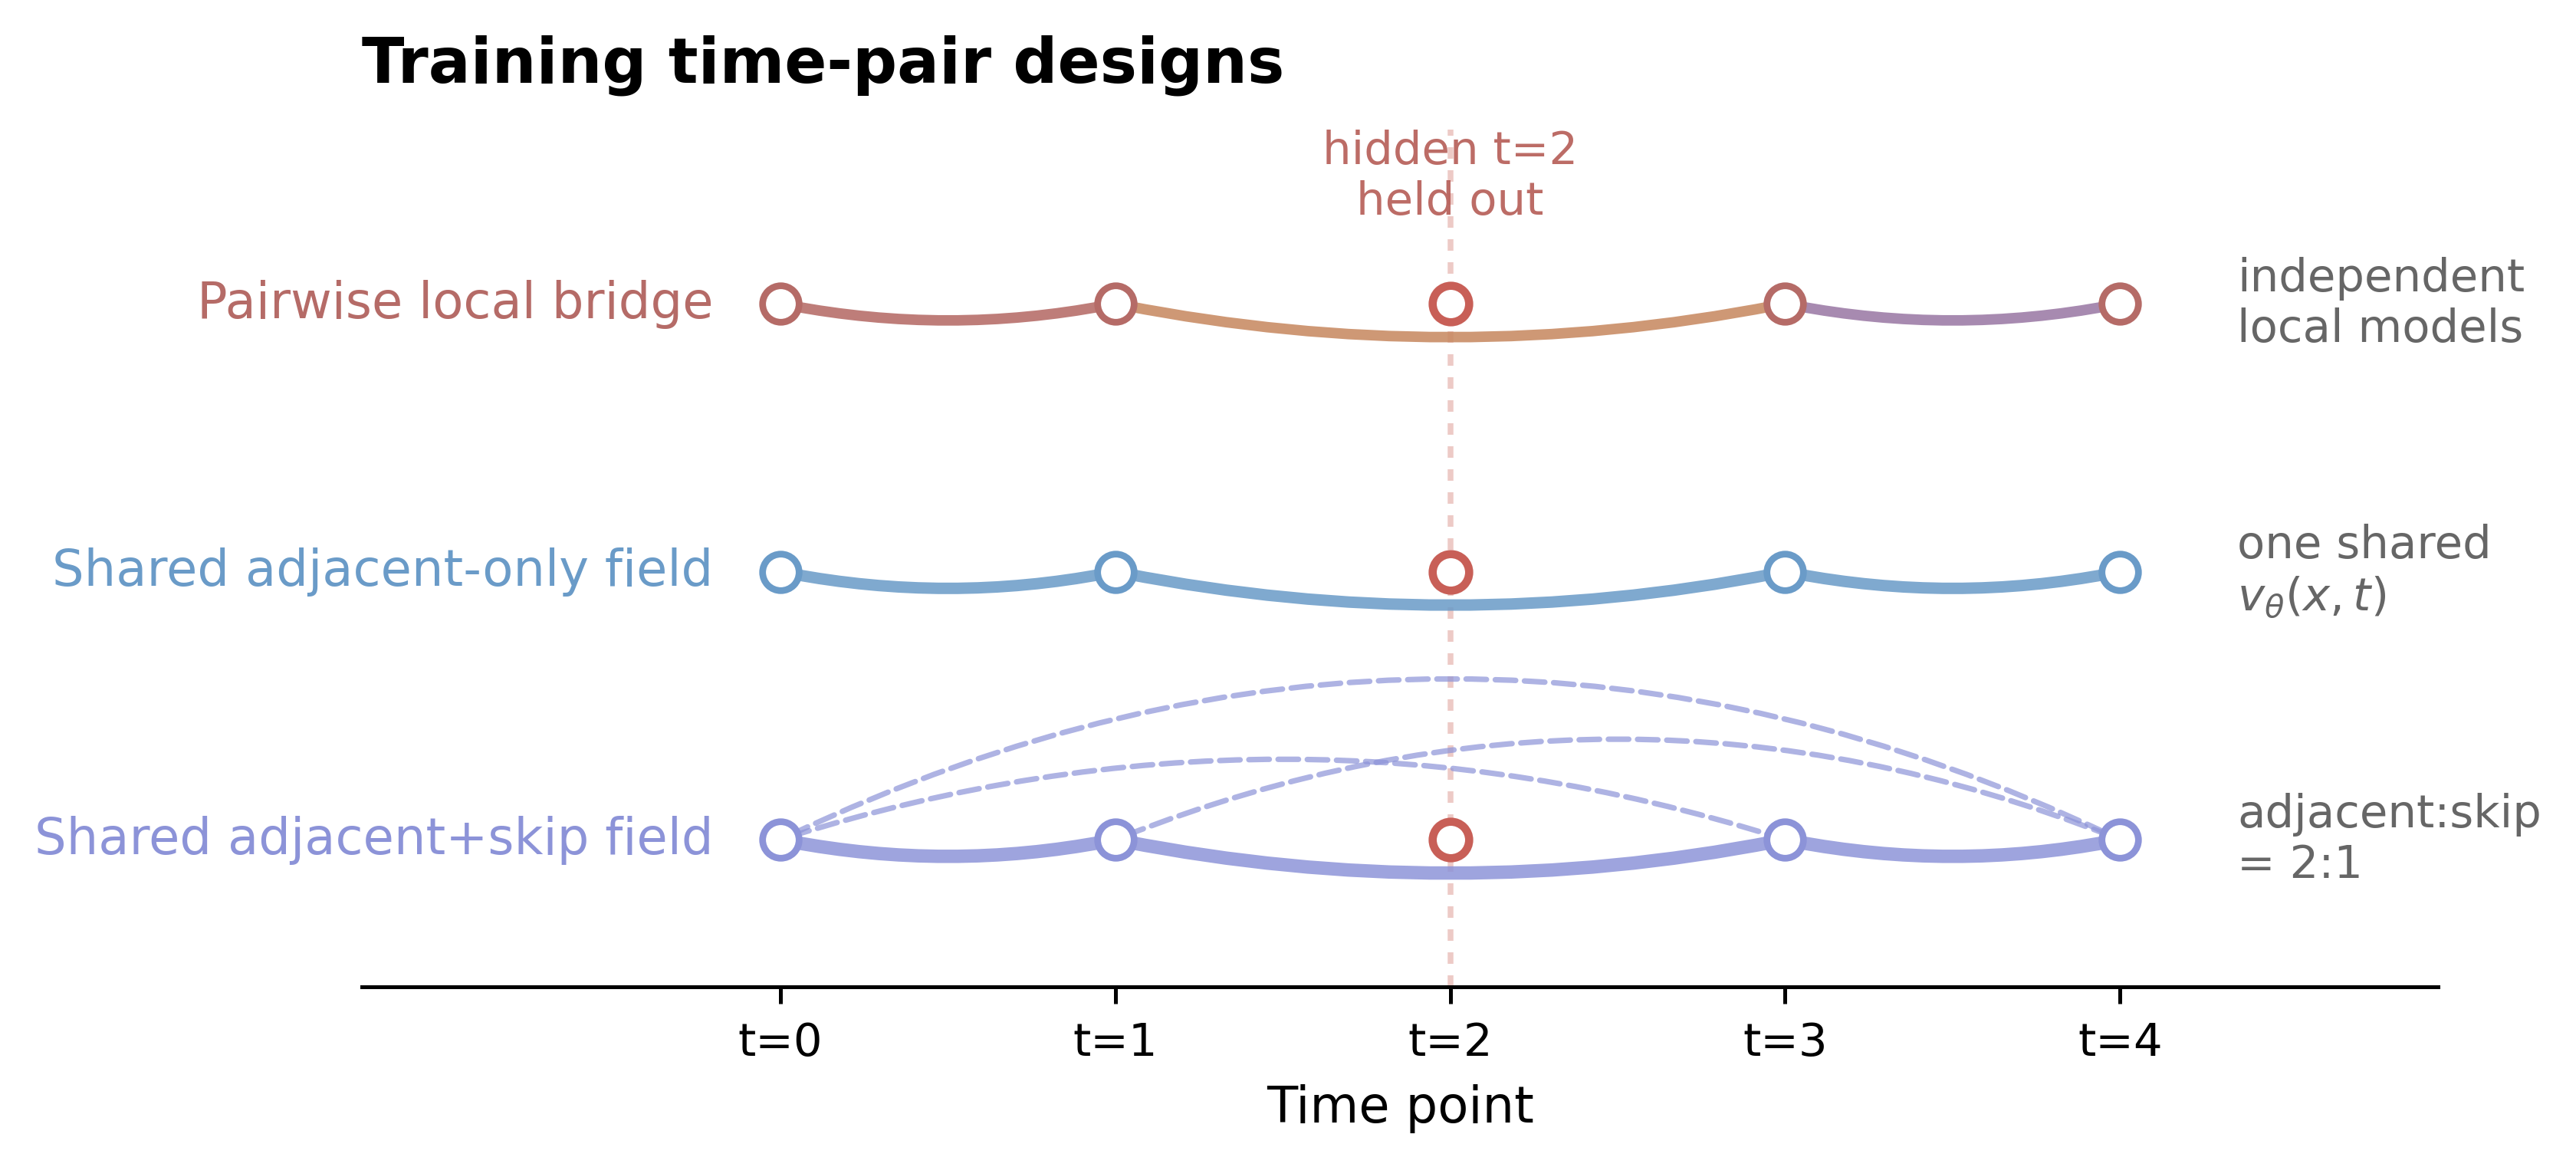

Generated time-pair design panel


In [17]:
fig5_1_paths = {}
fig5_1_paths.update(
    draw_fig5_1_time_pair_designs(
        adjacent_pairs=adjacent_pairs,
        skip_pairs=skip_pairs,
        fig_dir=FIG_DIR,
        display_fn=save_and_show,
    )
)

print("Generated time-pair design panel")


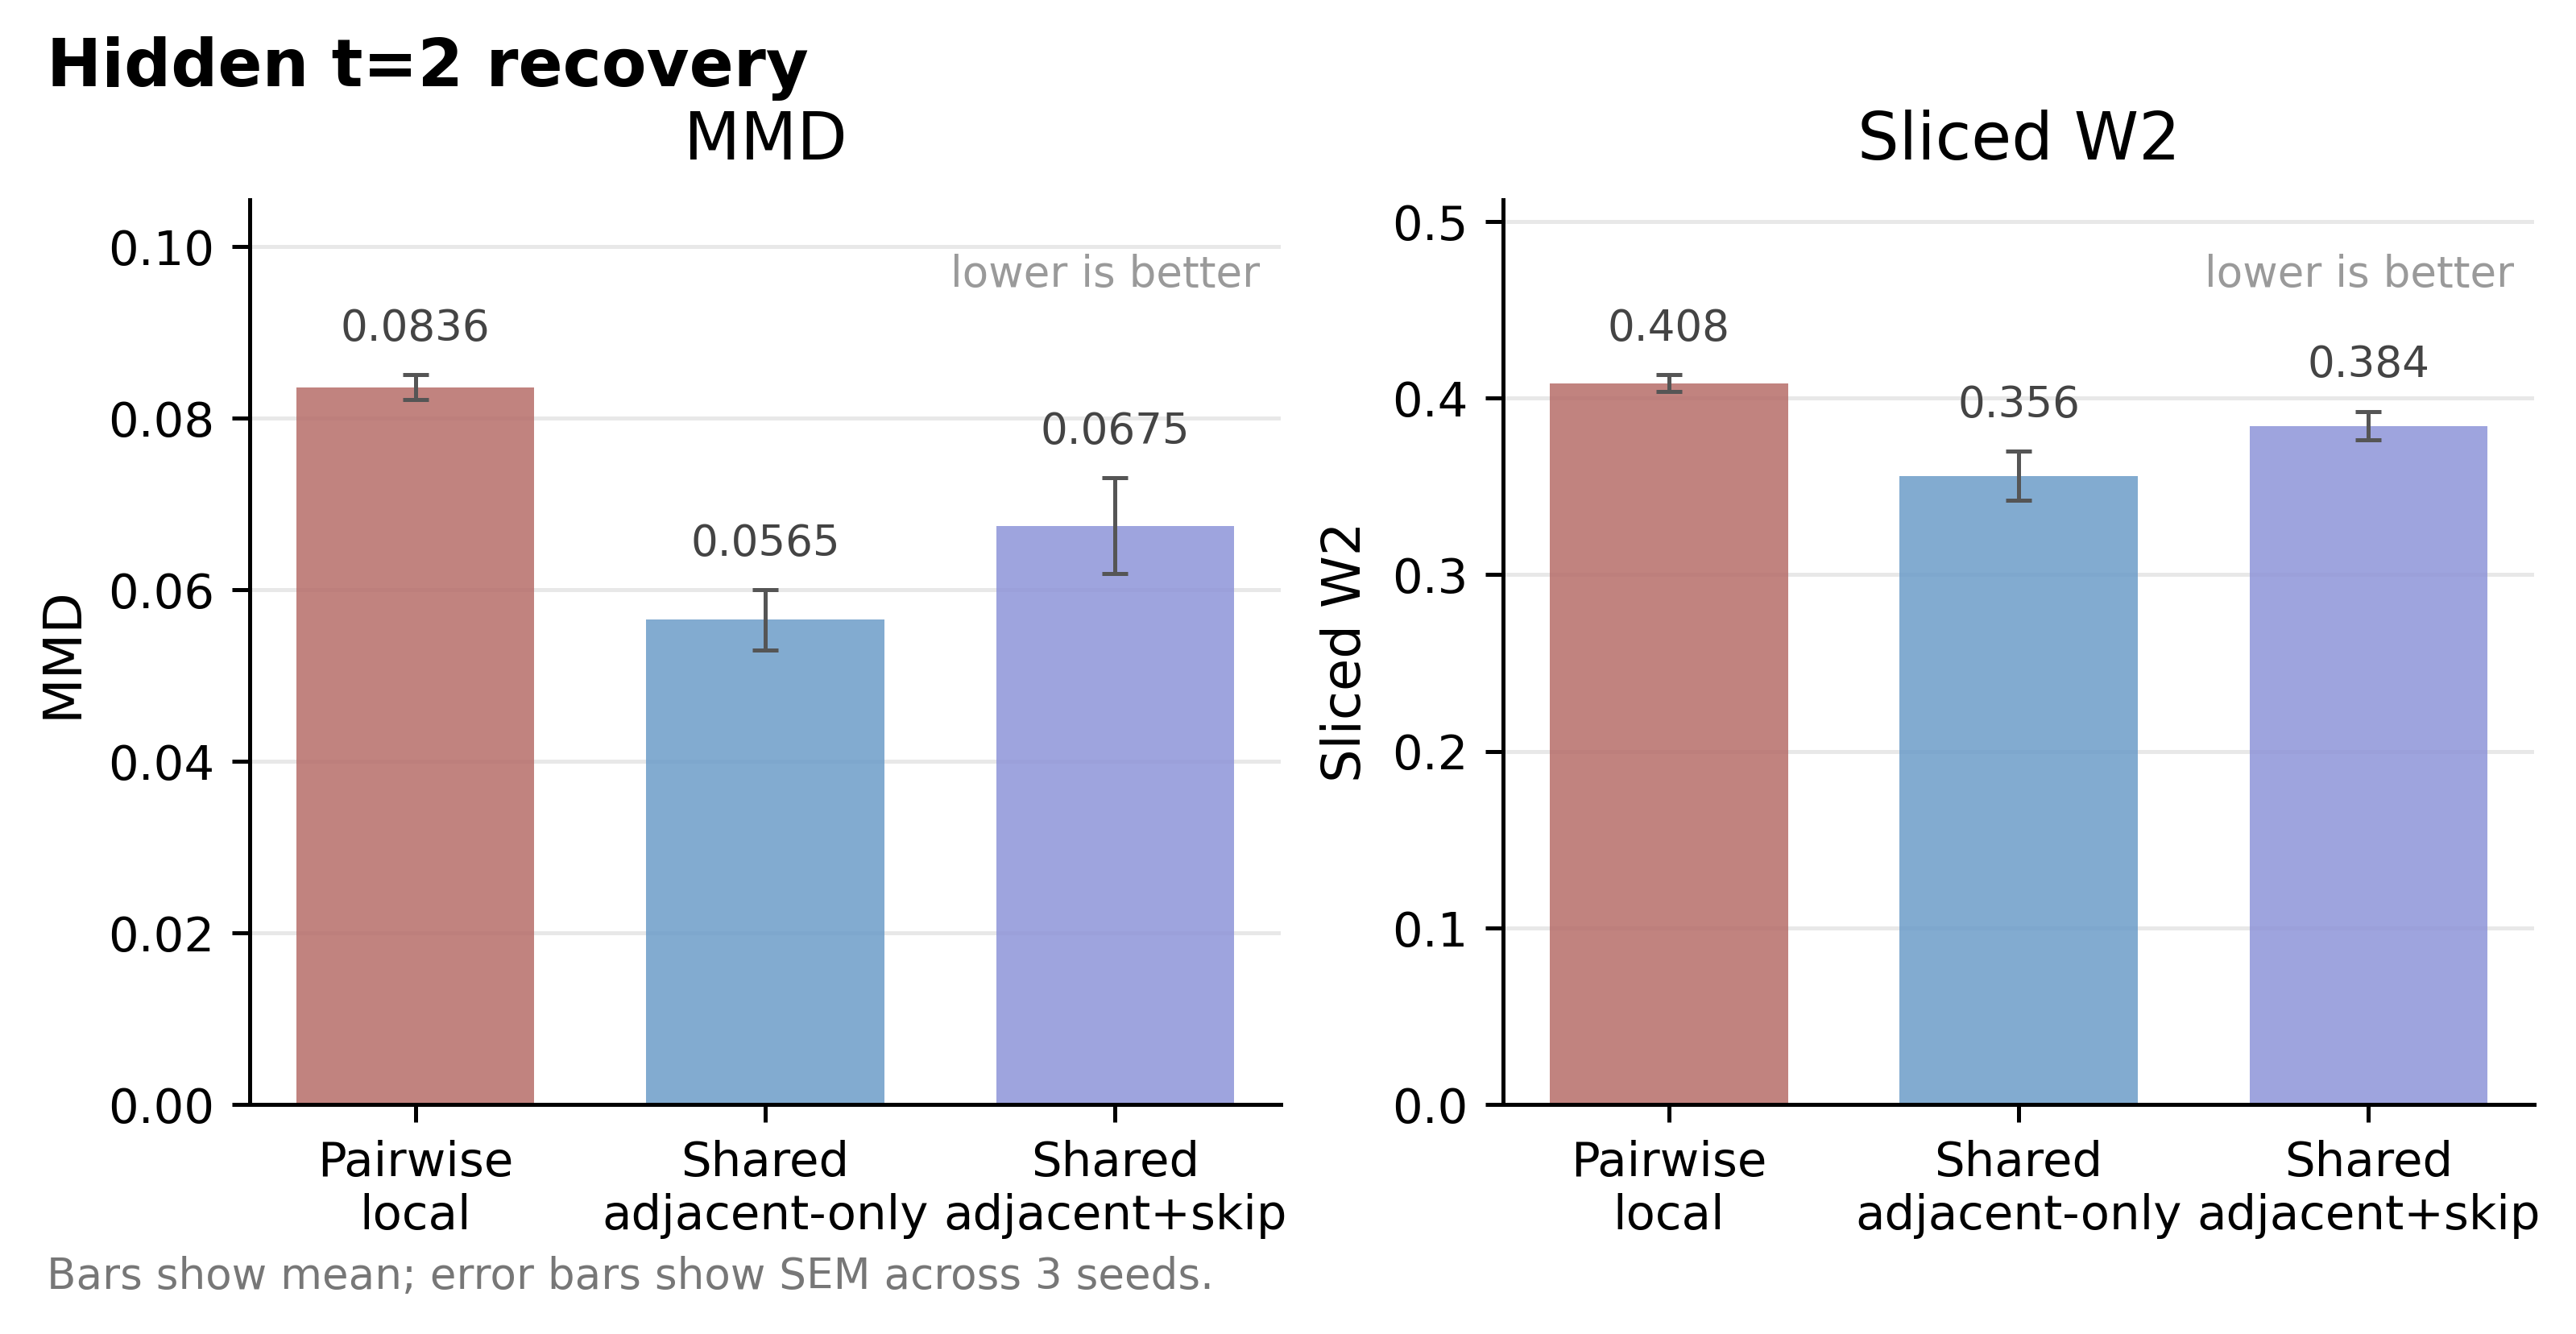

Hidden t=2 recovery values


,method,target,metric,mean,sem,sd,n_seeds,source_table,error_bar
0,Pairwise local bridge,hidden_t2,mmd_rbf,0.083634,0.001452,0.002516,3,tab_5_1_main_suite.csv,SEM across seeds
1,Pairwise local bridge,hidden_t2,sliced_w2,0.408452,0.004814,0.008338,3,tab_5_1_main_suite.csv,SEM across seeds
2,Shared adjacent-only field,hidden_t2,mmd_rbf,0.056502,0.003483,0.006033,3,tab_5_1_main_suite.csv,SEM across seeds
3,Shared adjacent-only field,hidden_t2,sliced_w2,0.355996,0.013849,0.023987,3,tab_5_1_main_suite.csv,SEM across seeds
4,Shared adjacent+skip field,hidden_t2,mmd_rbf,0.067479,0.005572,0.009651,3,tab_5_1_main_suite.csv,SEM across seeds
5,Shared adjacent+skip field,hidden_t2,sliced_w2,0.384300,0.008058,0.013958,3,tab_5_1_main_suite.csv,SEM across seeds


,method,target,metric,mean,sem,sd,n_seeds,source_table,error_bar
0,Pairwise local bridge,hidden_t2,mmd_rbf,0.083634,0.001452,0.002516,3,tab_5_1_main_suite.csv,SEM across seeds
1,Pairwise local bridge,hidden_t2,sliced_w2,0.408452,0.004814,0.008338,3,tab_5_1_main_suite.csv,SEM across seeds
2,Shared adjacent-only field,hidden_t2,mmd_rbf,0.056502,0.003483,0.006033,3,tab_5_1_main_suite.csv,SEM across seeds
3,Shared adjacent-only field,hidden_t2,sliced_w2,0.355996,0.013849,0.023987,3,tab_5_1_main_suite.csv,SEM across seeds
4,Shared adjacent+skip field,hidden_t2,mmd_rbf,0.067479,0.005572,0.009651,3,tab_5_1_main_suite.csv,SEM across seeds
5,Shared adjacent+skip field,hidden_t2,sliced_w2,0.384300,0.008058,0.013958,3,tab_5_1_main_suite.csv,SEM across seeds


In [18]:
fig5_1_paths.update(
    draw_fig5_1_hidden_t2_panel(
        fig5_1_hidden_t2_values,
        fig_dir=FIG_DIR,
        display_fn=save_and_show,
    )
)

print("Hidden t=2 recovery values")
preview_frame(
    fig5_1_hidden_t2_values[["method", "target", "metric", "mean", "sem", "sd", "n_seeds", "source_table", "error_bar"]],
    n=len(fig5_1_hidden_t2_values),
)


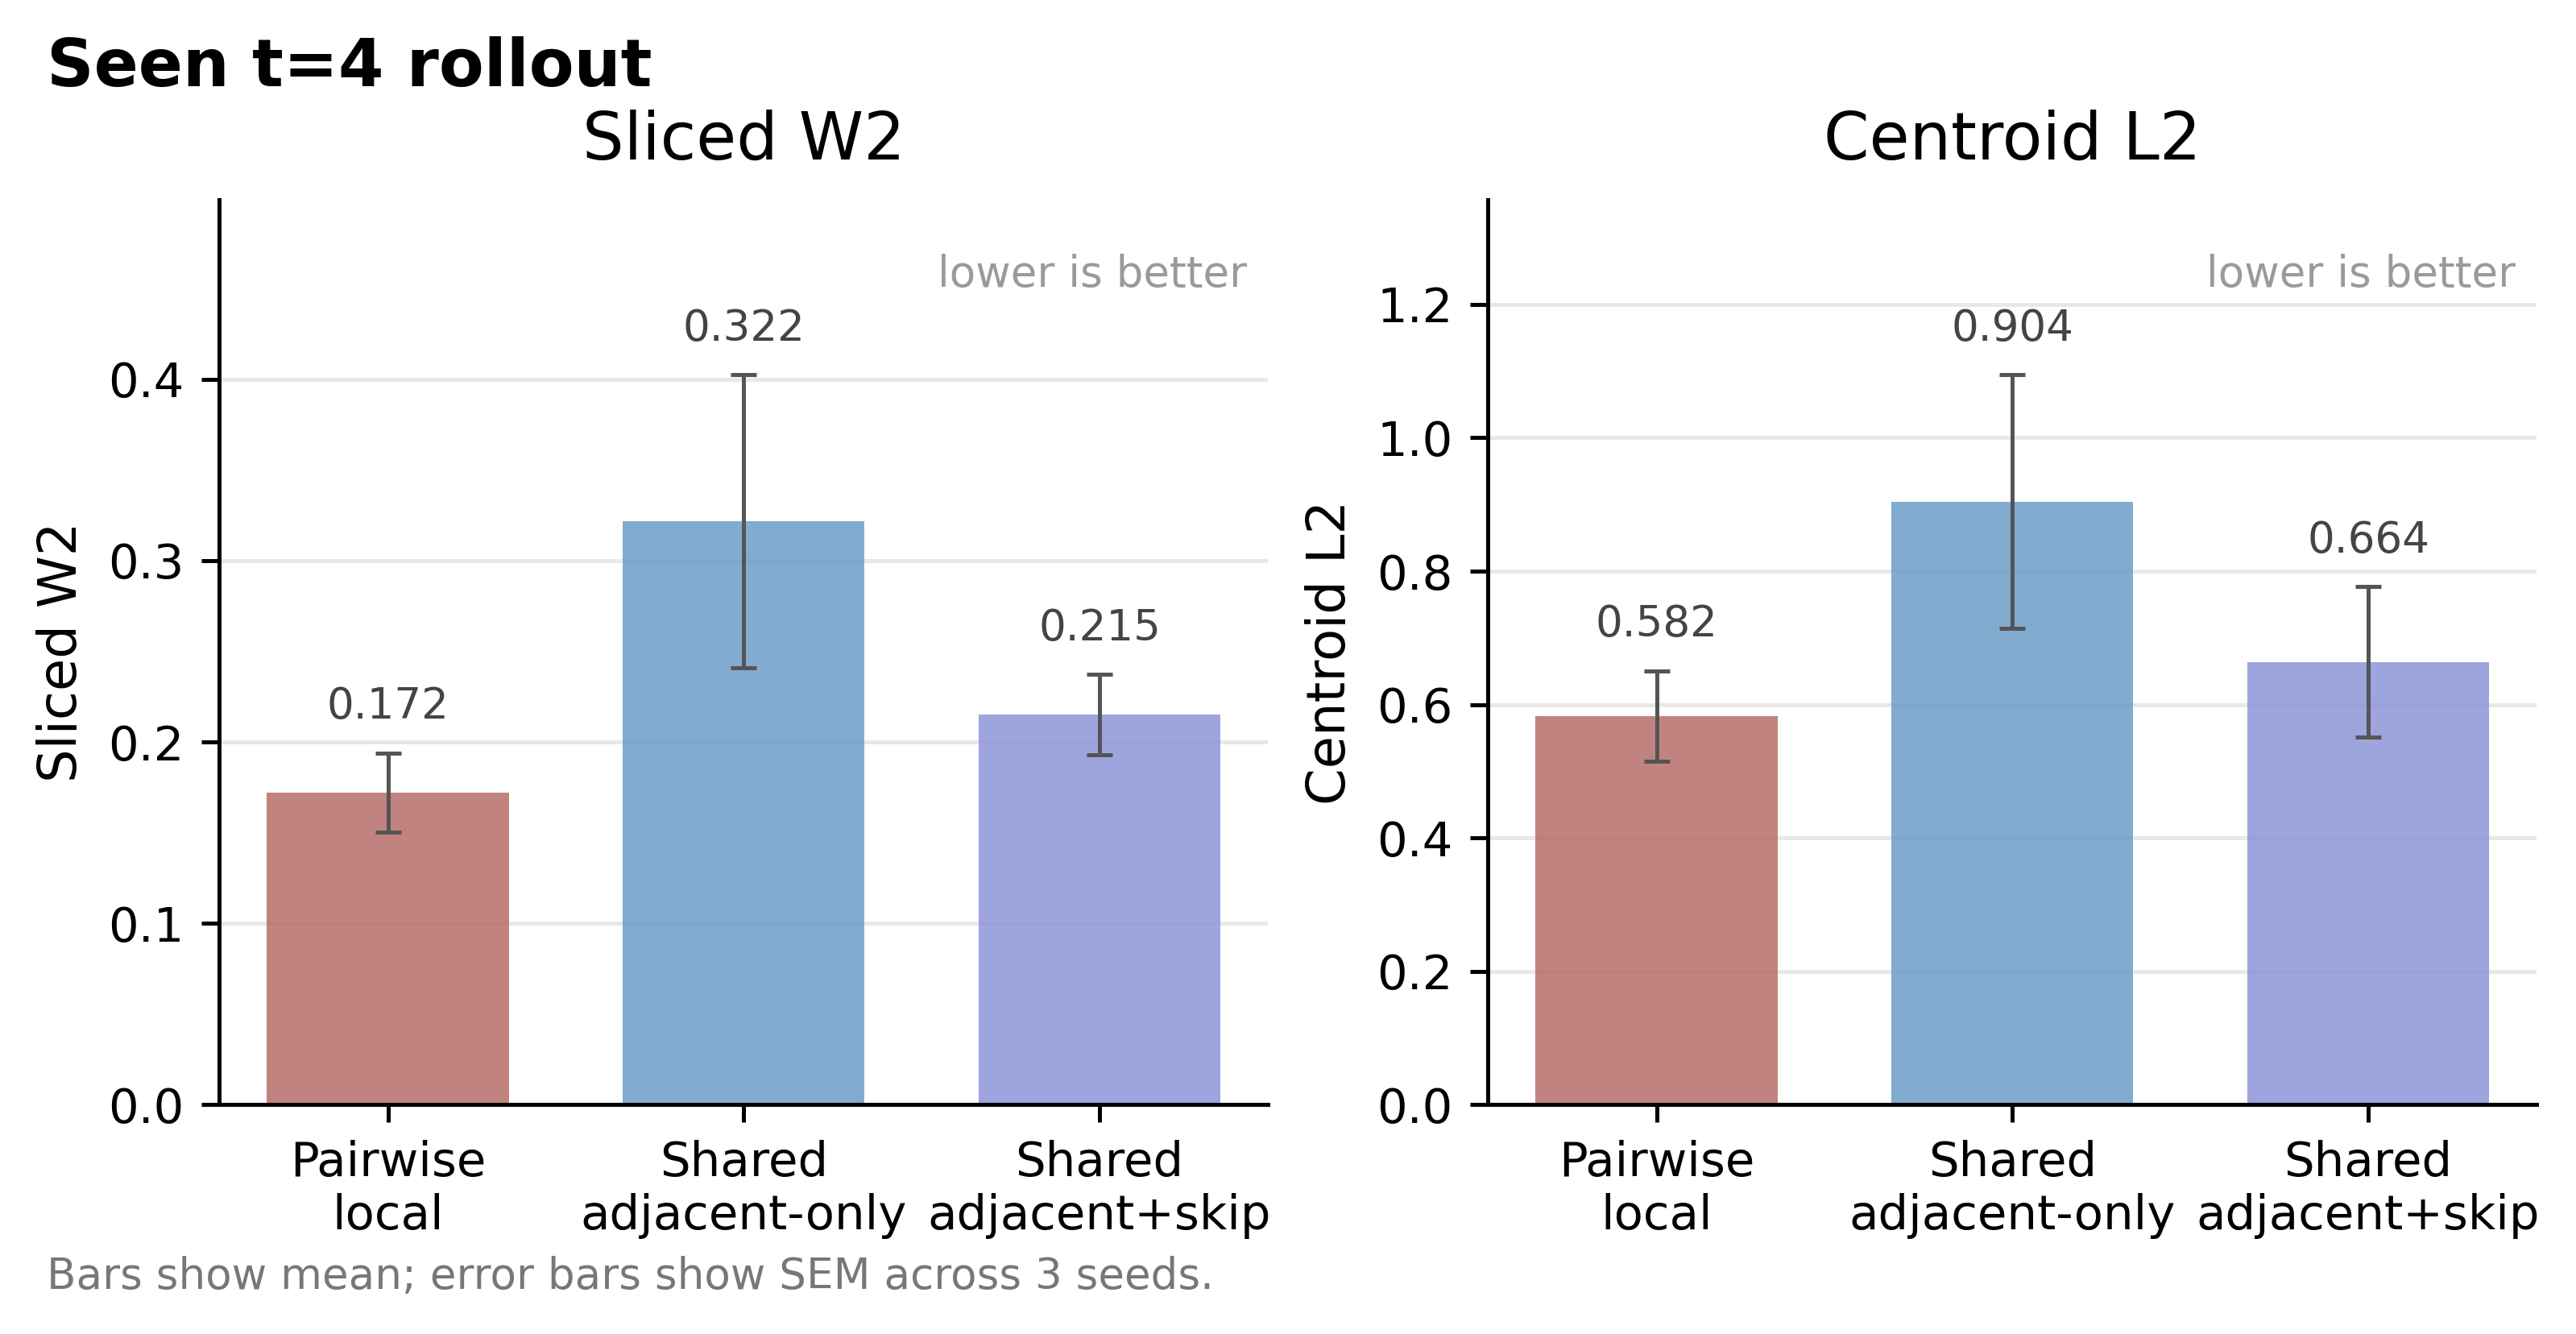

Seen t=4 rollout values


,method,target,metric,mean,sem,sd,n_seeds,source_table,error_bar
0,Pairwise local bridge,seen_t4,sliced_w2,0.172061,0.021686,0.037561,3,tab_5_1_main_suite.csv,SEM across seeds
1,Pairwise local bridge,seen_t4,centroid_l2,0.582460,0.067813,0.117455,3,tab_5_1_main_suite.csv,SEM across seeds
2,Shared adjacent-only field,seen_t4,sliced_w2,0.321605,0.080824,0.139992,3,tab_5_1_main_suite.csv,SEM across seeds
3,Shared adjacent-only field,seen_t4,centroid_l2,0.904182,0.190381,0.329750,3,tab_5_1_main_suite.csv,SEM across seeds
4,Shared adjacent+skip field,seen_t4,sliced_w2,0.214999,0.022097,0.038274,3,tab_5_1_main_suite.csv,SEM across seeds
5,Shared adjacent+skip field,seen_t4,centroid_l2,0.663832,0.112625,0.195072,3,tab_5_1_main_suite.csv,SEM across seeds


,method,target,metric,mean,sem,sd,n_seeds,source_table,error_bar
0,Pairwise local bridge,seen_t4,sliced_w2,0.172061,0.021686,0.037561,3,tab_5_1_main_suite.csv,SEM across seeds
1,Pairwise local bridge,seen_t4,centroid_l2,0.582460,0.067813,0.117455,3,tab_5_1_main_suite.csv,SEM across seeds
2,Shared adjacent-only field,seen_t4,sliced_w2,0.321605,0.080824,0.139992,3,tab_5_1_main_suite.csv,SEM across seeds
3,Shared adjacent-only field,seen_t4,centroid_l2,0.904182,0.190381,0.329750,3,tab_5_1_main_suite.csv,SEM across seeds
4,Shared adjacent+skip field,seen_t4,sliced_w2,0.214999,0.022097,0.038274,3,tab_5_1_main_suite.csv,SEM across seeds
5,Shared adjacent+skip field,seen_t4,centroid_l2,0.663832,0.112625,0.195072,3,tab_5_1_main_suite.csv,SEM across seeds


In [19]:
fig5_1_paths.update(
    draw_fig5_1_seen_t4_panel(
        fig5_1_seen_t4_values,
        fig_dir=FIG_DIR,
        display_fn=save_and_show,
    )
)

print("Seen t=4 rollout values")
preview_frame(
    fig5_1_seen_t4_values[["method", "target", "metric", "mean", "sem", "sd", "n_seeds", "source_table", "error_bar"]],
    n=len(fig5_1_seen_t4_values),
)


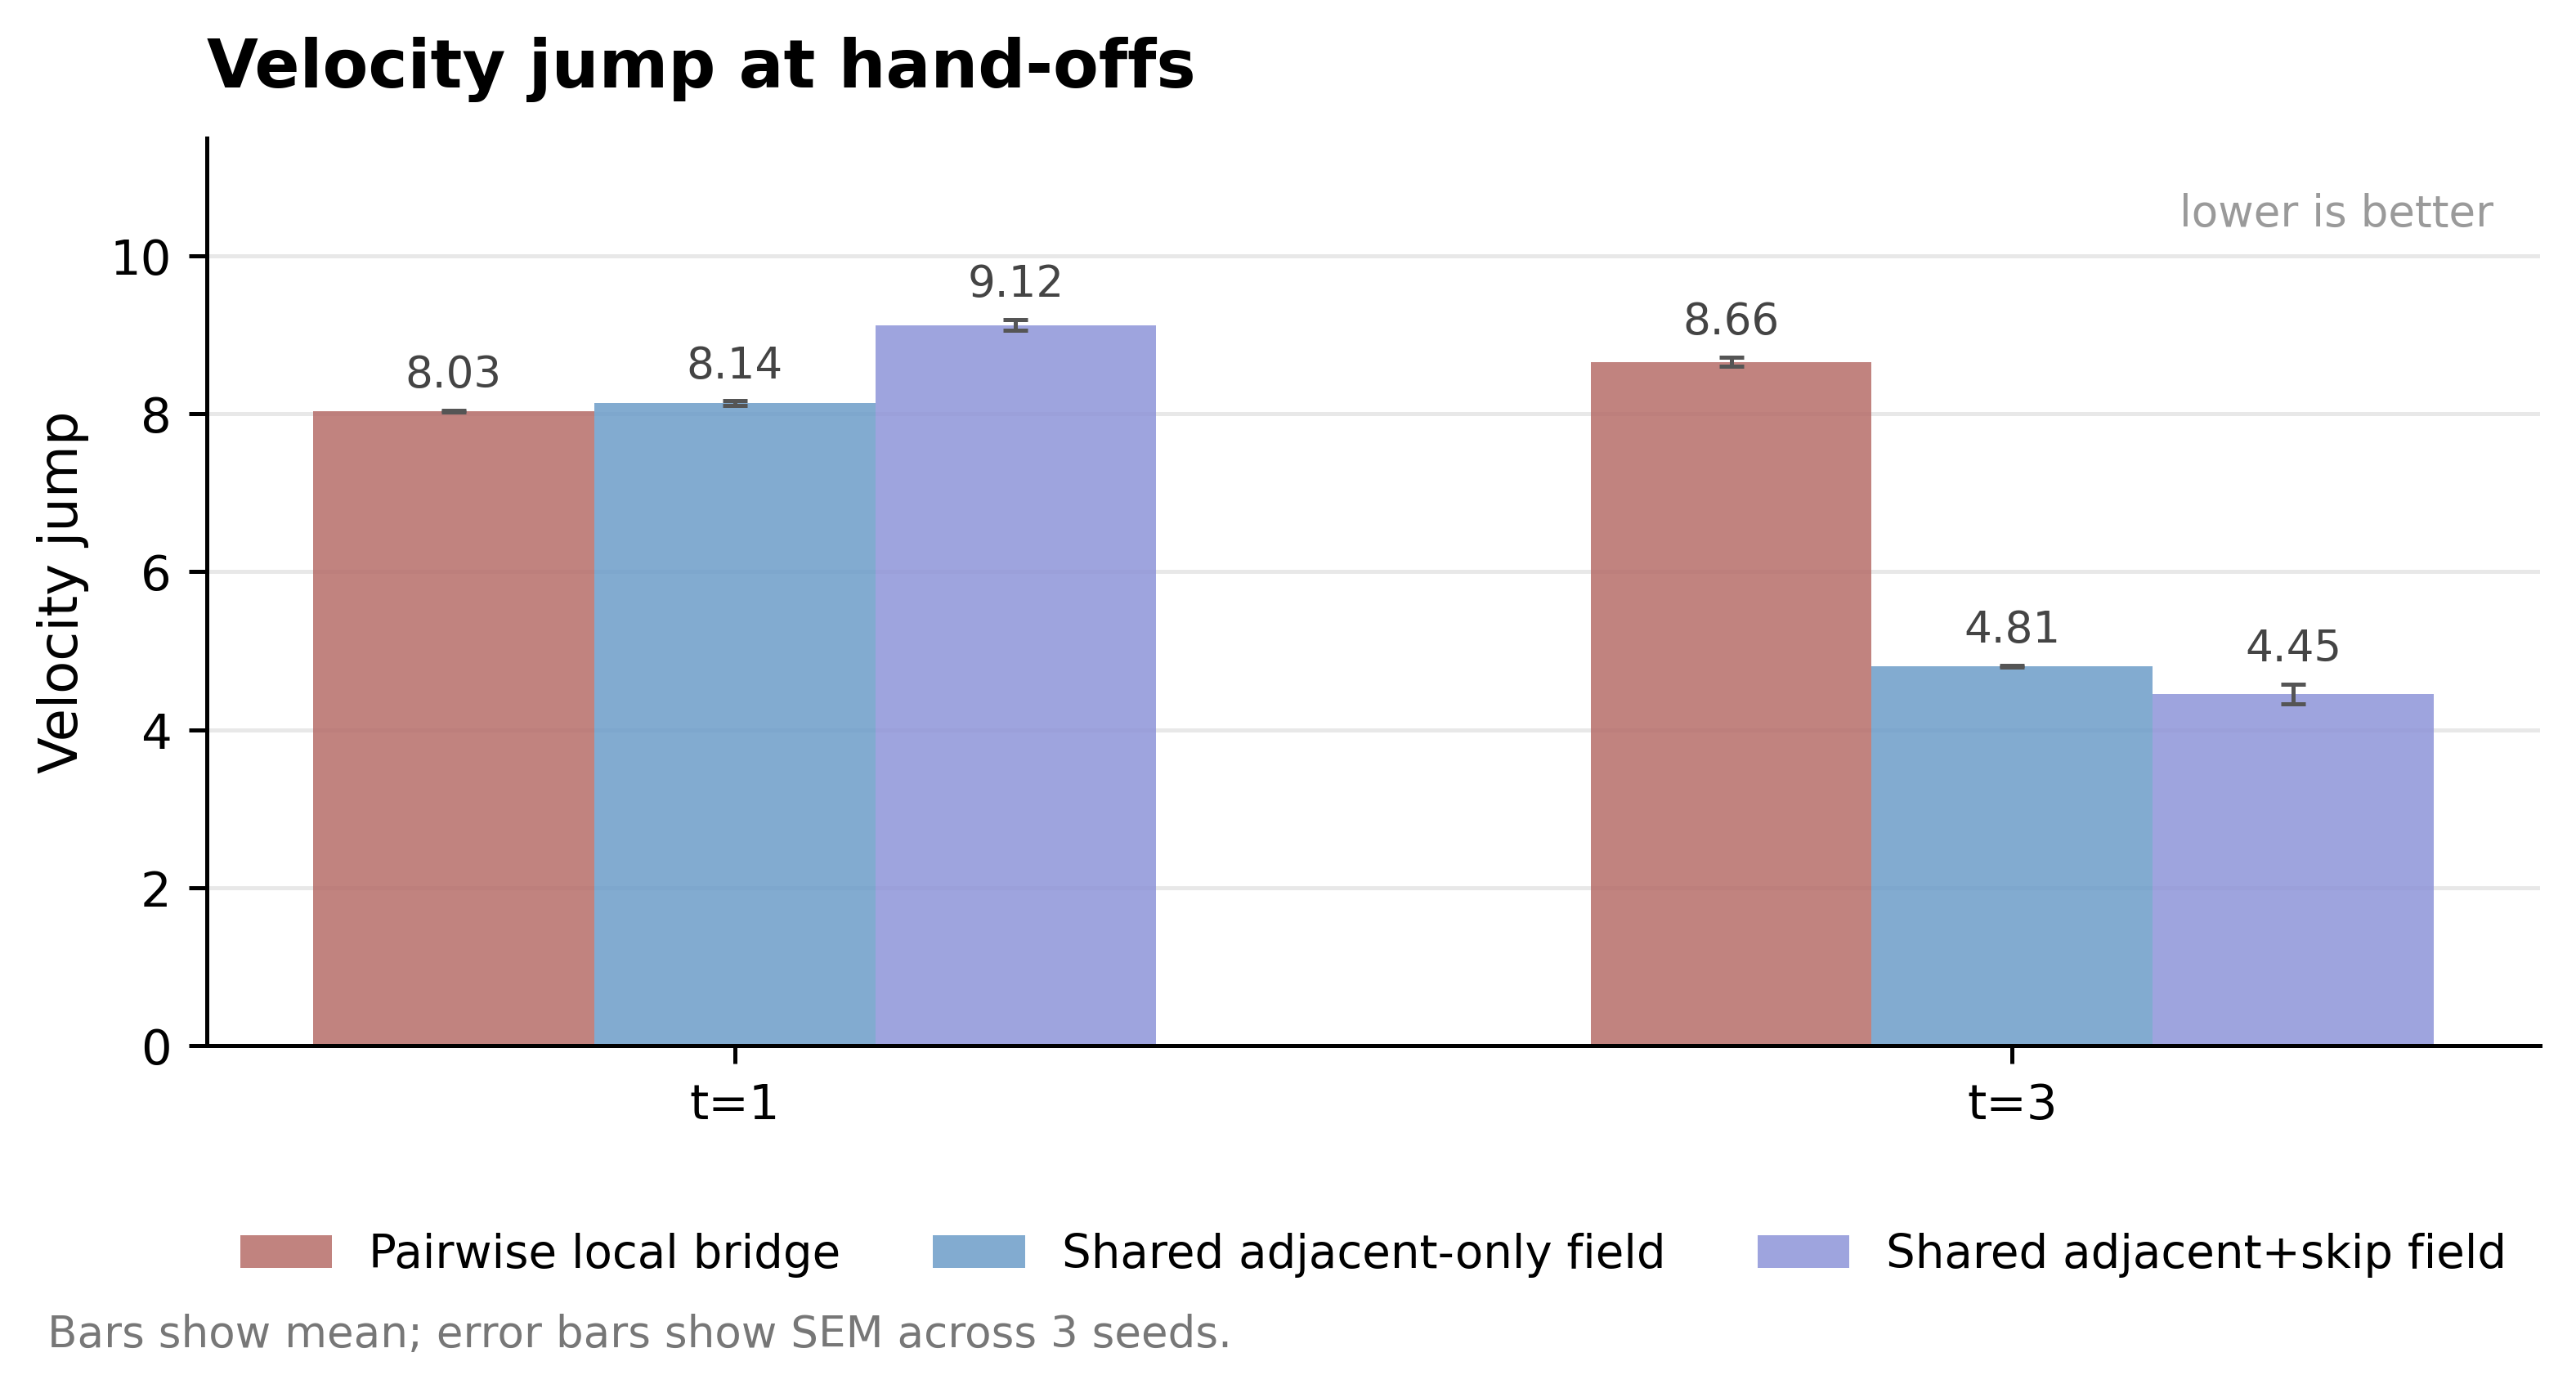

Velocity jump values


,method,boundary,metric,mean,sem,sd,n_seeds,source_table,error_bar
0,Pairwise local bridge,t1,velocity_jump_mean_l2,8.032818,0.014671,0.025411,3,tab_5_1_main_suite_diag.csv,SEM across seeds
1,Shared adjacent-only field,t1,velocity_jump_mean_l2,8.135409,0.026908,0.046606,3,tab_5_1_main_suite_diag.csv,SEM across seeds
2,Shared adjacent+skip field,t1,velocity_jump_mean_l2,9.122618,0.068071,0.117903,3,tab_5_1_main_suite_diag.csv,SEM across seeds
3,Pairwise local bridge,t3,velocity_jump_mean_l2,8.657238,0.055341,0.095853,3,tab_5_1_main_suite_diag.csv,SEM across seeds
4,Shared adjacent-only field,t3,velocity_jump_mean_l2,4.805779,0.009419,0.016314,3,tab_5_1_main_suite_diag.csv,SEM across seeds
5,Shared adjacent+skip field,t3,velocity_jump_mean_l2,4.451229,0.125653,0.217638,3,tab_5_1_main_suite_diag.csv,SEM across seeds


,method,boundary,metric,mean,sem,sd,n_seeds,source_table,error_bar
0,Pairwise local bridge,t1,velocity_jump_mean_l2,8.032818,0.014671,0.025411,3,tab_5_1_main_suite_diag.csv,SEM across seeds
1,Shared adjacent-only field,t1,velocity_jump_mean_l2,8.135409,0.026908,0.046606,3,tab_5_1_main_suite_diag.csv,SEM across seeds
2,Shared adjacent+skip field,t1,velocity_jump_mean_l2,9.122618,0.068071,0.117903,3,tab_5_1_main_suite_diag.csv,SEM across seeds
3,Pairwise local bridge,t3,velocity_jump_mean_l2,8.657238,0.055341,0.095853,3,tab_5_1_main_suite_diag.csv,SEM across seeds
4,Shared adjacent-only field,t3,velocity_jump_mean_l2,4.805779,0.009419,0.016314,3,tab_5_1_main_suite_diag.csv,SEM across seeds
5,Shared adjacent+skip field,t3,velocity_jump_mean_l2,4.451229,0.125653,0.217638,3,tab_5_1_main_suite_diag.csv,SEM across seeds


In [20]:
fig5_1_paths.update(
    draw_fig5_1_velocity_jump_panel(
        fig5_1_velocity_jump_values,
        fig_dir=FIG_DIR,
        display_fn=save_and_show,
    )
)

print("Velocity jump values")
preview_frame(
    fig5_1_velocity_jump_values[["method", "boundary", "metric", "mean", "sem", "sd", "n_seeds", "source_table", "error_bar"]],
    n=len(fig5_1_velocity_jump_values),
)


In [21]:
fig5_1_path_table = register_fig5_1_artifacts(
    fig5_1_paths,
    panel_sources=fig5_1_panel_sources,
    missing_entries=fig5_1_missing_entries,
    run_summary_path=run_summary_path,
    project_root=PROJECT_ROOT,
)
artifact_paths.update(fig5_1_paths)
preview_frame(fig5_1_path_table, n=len(fig5_1_path_table))


,artifact,relative_path,absolute_path
1,fig5_1_hidden_t2_recovery_png,figures/ch05/fig5_1_hidden_t2_recovery.png,/import/macyang_home4/xmabs/flow_matching_for_...
2,fig5_1_seen_t4_rollout_png,figures/ch05/fig5_1_seen_t4_rollout.png,/import/macyang_home4/xmabs/flow_matching_for_...
0,fig5_1_time_pair_designs_png,figures/ch05/fig5_1_time_pair_designs.png,/import/macyang_home4/xmabs/flow_matching_for_...
3,fig5_1_velocity_jump_png,figures/ch05/fig5_1_velocity_jump.png,/import/macyang_home4/xmabs/flow_matching_for_...


,artifact,relative_path,absolute_path
1,fig5_1_hidden_t2_recovery_png,figures/ch05/fig5_1_hidden_t2_recovery.png,/import/macyang_home4/xmabs/flow_matching_for_...
2,fig5_1_seen_t4_rollout_png,figures/ch05/fig5_1_seen_t4_rollout.png,/import/macyang_home4/xmabs/flow_matching_for_...
0,fig5_1_time_pair_designs_png,figures/ch05/fig5_1_time_pair_designs.png,/import/macyang_home4/xmabs/flow_matching_for_...
3,fig5_1_velocity_jump_png,figures/ch05/fig5_1_velocity_jump.png,/import/macyang_home4/xmabs/flow_matching_for_...


## Take-aways

- *Finding 1* — The time-course suite tests hidden intermediate recovery, seen endpoint rollout, and velocity hand-off smoothness across EB snapshots.
- *Finding 2* — Pairwise local bridges and shared global bridges differ in topology: local models stitch adjacent intervals, while shared fields learn across configured source-target pairs.
- *Finding 3* — Endpoint metrics and hand-off diagnostics feed paper-facing tables and independent Figure 5.1 panels rather than a single broad overview image.

Next: → ch5_2
